<a href="https://colab.research.google.com/github/VemuriPavanateja2007/Computer-Vision/blob/main/Practicals/CV_Pract_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd "/content/drive/MyDrive/Colab Notebooks/Computer Vision/Data For CV"

/content/drive/MyDrive/Colab Notebooks/Computer Vision/Data For CV


SIFT Results:
Number of keypoints found: 381
Shape of descriptors: (381, 128)

SURF is not available in this OpenCV installation (patent issue).


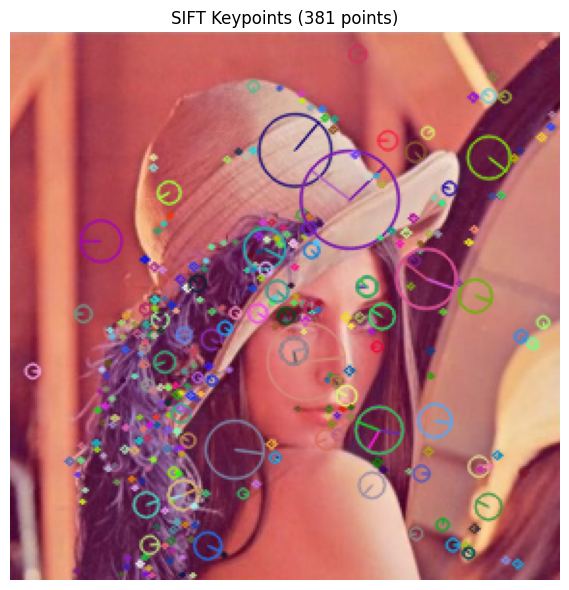

In [ ]:
# Load image
img = cv2.imread('lena.jpg')
if img is None:
    print("Error: Image not found!")
else:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # ---------- SIFT ----------
    sift = cv2.SIFT_create()                   # Create SIFT object
    keypoints_sift, descriptors_sift = sift.detectAndCompute(gray, None)

    # Draw keypoints on the image
    img_sift = cv2.drawKeypoints(img, keypoints_sift, None,
                                  flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

    print("SIFT Results:")
    print("Number of keypoints found:", len(keypoints_sift))
    print("Shape of descriptors:", descriptors_sift.shape)   # (number of points, 128)

    # ---------- Try SURF (may not work on all systems) ----------
    try:
        surf = cv2.xfeatures2d.SURF_create(400)   # 400 is Hessian threshold
        keypoints_surf, descriptors_surf = surf.detectAndCompute(gray, None)
        img_surf = cv2.drawKeypoints(img, keypoints_surf, None,
                                     flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
        print("\nSURF Results:")
        print("Number of keypoints found:", len(keypoints_surf))
        print("Shape of descriptors:", descriptors_surf.shape)
        surf_available = True
    except:
        print("\nSURF is not available in this OpenCV installation (patent issue).")
        surf_available = False

    # Display
    plt.figure(figsize=(15, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(img_sift, cv2.COLOR_BGR2RGB))
    plt.title(f'SIFT Keypoints ({len(keypoints_sift)} points)')
    plt.axis('off')

    if surf_available:
        plt.subplot(1, 2, 2)
        plt.imshow(cv2.cvtColor(img_surf, cv2.COLOR_BGR2RGB))
        plt.title(f'SURF Keypoints ({len(keypoints_surf)} points)')
        plt.axis('off')

    plt.tight_layout()
    plt.show()